In [1]:
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt
import h5py
from localized_2d import WfnParams, Wavefunction, HamiltParams, Hamilt

In [2]:
def get_e_loc_for_coupling(dir,Mx,My,tx,ty,B,V_0_arr):
    e_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_arr_tun = np.zeros(len(V_0_arr), dtype=complex)
    
    e_T_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_V_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_B_arr = np.zeros(len(V_0_arr), dtype=complex)

    Tx_arr = np.zeros(len(V_0_arr), dtype=complex)
    Ty_arr = np.zeros(len(V_0_arr), dtype=complex)

    for i in range(len(V_0_arr)):
        V_0 = V_0_arr[i]
        file_path = dir+'data_B_'+str(B)+'_V0_'+str(V_0)+'_tx_'+str(tx)+'_ty_'+str(ty)+'_'+str(int(Mx))+'x'+str(int(My))+'.h5'

        with h5py.File(file_path, 'r') as f:
            phi_data = f["wfn"][...]
            Mx = f["Mx"][...]
            My = f["My"][...]
            n = f["n"][...]
            B = f["B"][...]
            tx = f["tx"][...]
            ty = f["ty"][...]
            V_0 = f["V0"][...]
            e_tun = f["e_tun"][...]
            v_tun = f["v_tun"][...]

        wfnpar = WfnParams(Mx, My, n)
        Mx, My, n, x, k2 = wfnpar.read()

        wfn = Wavefunction(wfnpar, array=phi_data)

        hamiltpar = HamiltParams(B, tx, ty, V_0)

        H = Hamilt(wfnpar, hamiltpar)
        energy_tot, energy_rot, energy_ele, energy_int = H.calculate_energy(wfn)
        Tx, Ty = H.calc_Tx_Ty(wfn)
        
        e_arr[i] = energy_tot
        e_T_arr[i] = energy_ele
        e_B_arr[i] = np.sum(energy_rot)
        e_V_arr[i] = np.sum(energy_int)

        e_arr_tun[i] = e_tun[0]

        Tx_arr[i] = Tx
        Ty_arr[i] = Ty
        
    return e_arr, e_arr_tun, e_T_arr, e_B_arr, e_V_arr, Tx, Ty

def get_state_e_loc_data(dir,Mx,My,tx_arr,ty_arr,B,V_0_arr):
    e_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    e_tun_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)

    e_T_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    e_B_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    e_V_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    
    Tx_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    Ty_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    for i in range(len(tx_arr)):
        tx = tx_arr[i]
        ty = ty_arr[i]

        e_flp, e_tun, e_flp_T, e_flp_B, e_flp_V, Tx_flp, Ty_flp = get_e_loc_for_coupling(dir=dir,Mx=Mx,My=My,tx=tx,ty=ty,B=B,V_0_arr=V_0_arr)

        e_arr[i] = e_flp
        e_tun_arr[i] = e_tun 
        
        e_T_arr[i] = e_flp_T
        e_B_arr[i] = e_flp_B
        e_V_arr[i] = e_flp_V


        Tx_arr[i] = Tx_flp
        Ty_arr[i] = Ty_flp

    return e_arr, e_T_arr, e_B_arr, e_V_arr, Tx_arr, Ty_arr

''' 
TODO: add here wavefunction analysis file
'''

' \nTODO: add here wavefunction analysis file\n'

In [3]:
'''
Get State Properties for a phase diagram scan in the delta_t-V_0 plane
'''
V_0_arr = np.array([0.7])

Mx = 5
My = 5
tx = 0.5
ty = 0.5
B = 1e-2

dir = 'data_localized/'
e, e_tun, e_T, e_B, e_V, Tx, Ty = get_e_loc_for_coupling(dir=dir,Mx=Mx,My=My,tx=tx,ty=ty,B=B,V_0_arr=V_0_arr)

print('E     =', e, '\nE_tun =', e_tun, '\nE_T   =', e_T, '\nE_B   =', e_B, '\nE_V   =', e_V, '\nTx    =', Tx, '\nTy    =', Ty)

E     = [-3.09966484+6.82541461e-19j] 
E_tun = [-3.09975396+6.82769673e-19j] 
E_T   = [-1.08308813+0.j] 
E_B   = [0.1544418+6.82541461e-19j] 
E_V   = [-2.17101851+0.j] 
Tx    = (1.083079922011876+0j) 
Ty    = (1.0830963437010852+0j)


In [4]:
'''
Get State Properties for a phase diagram scan in the delta_t-V_0 plane
'''
V_0_arr = np.array([0.7])

Mx = 5
My = 5
tx_arr = np.array([0.5])
ty_arr = np.array([0.5])
B = 1e-2

qx=0.0
qy=0.0

dir='data_localized/'
e_arr, e_T_arr, e_B_arr, e_V_arr, Tx_arr, Ty_arr = get_state_e_loc_data(dir=dir,Mx=Mx,My=My,tx_arr=tx_arr,ty_arr=ty_arr,B=B,V_0_arr=V_0_arr)

tx = 0.5  ty = 0.5


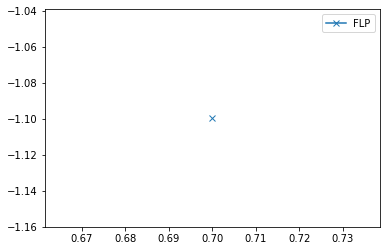

In [5]:
delta_t_index = 0
print('tx =', tx_arr[delta_t_index], ' ty =', ty_arr[delta_t_index])

plt.plot(V_0_arr, e_arr[delta_t_index].real+2, marker='x', label=r'FLP')

plt.legend()